In [419]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
%matplotlib inline 

In [420]:
df=pd.read_csv("/kaggle/input/phising-data/Phishing.csv")

In [421]:
df.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,NumHash,NumNumericChars,NoHttps,RandomString,IpAddress,DomainInSubdomains,DomainInPaths,HttpsInHostname,HostnameLength,PathLength,QueryLength,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,PctExtHyperlinks,PctExtResourceUrls,ExtFavicon,InsecureForms,RelativeFormAction,ExtFormAction,AbnormalFormAction,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,FakeLinkInStatusBar,RightClickDisabled,PopUpWindow,SubmitInfoToEmail,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,21,44,0,0,0,0,0.000,0.250000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,0,2,1,0,41,1,0,0,0,0,0,17,16,103,0,1,0,0.000,0.000000,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,27,24,0,0,0,0,0.375,1.000000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,22,50,0,0,0,1,1.000,0.095238,1,1,0,0,0,0.0,1,0,0,0,1,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,0,0,0,0,2,1,1,0,0,1,0,10,29,0,0,0,0,1.000,1.000000,0,0,0,1,0,0.0,1,0,0,0,0,1,0,0,1,1,-1,0,-1,-1,1


In [422]:
df.shape

(10000, 50)

In [423]:
df.isnull().sum()

id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSlashInPath                     0


In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [425]:
df.describe()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,NumHash,NumNumericChars,NoHttps,RandomString,IpAddress,DomainInSubdomains,DomainInPaths,HttpsInHostname,HostnameLength,PathLength,QueryLength,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,PctExtHyperlinks,PctExtResourceUrls,ExtFavicon,InsecureForms,RelativeFormAction,ExtFormAction,AbnormalFormAction,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,FakeLinkInStatusBar,RightClickDisabled,PopUpWindow,SubmitInfoToEmail,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.445100,0.586800,3.300300,70.264100,1.818000,0.138900,0.000300,0.013100,0.32320,0.073800,0.458600,0.277200,0.002300,5.810300,0.988800,0.52520,0.017200,0.022200,0.428900,0.0,18.82430,35.564900,8.606500,0.000900,0.109300,0.057100,0.241334,0.392932,0.167200,0.844000,0.248700,0.1018,0.057600,0.136136,0.215300,0.005500,0.014000,0.004900,0.128800,0.339600,0.03220,0.030400,0.956600,0.020200,0.353300,0.793200,0.173400,0.314100,0.500000
std,2886.89568,1.346836,0.751214,1.863241,33.369877,3.106258,0.545744,0.017319,0.113709,1.11466,0.622248,1.344793,1.117356,0.047906,9.617877,0.105241,0.49939,0.130023,0.147341,0.494944,0.0,8.11654,24.588502,24.313053,0.029988,0.368737,0.232045,0.342370,0.387292,0.373173,0.362873,0.432281,0.3024,0.232997,0.312413,0.411051,0.073961,0.117496,0.069832,0.334995,0.473597,0.17654,0.171694,0.248037,0.820036,0.888908,0.521019,0.755771,0.897843,0.500025
min,1.00000,1.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,4.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,2500.75000,2.000000,0.000000,2.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.0,14.00000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030303,0.000000,1.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,-1.000000,-1.000000,1.000000,0.000000,-1.000000,0.000000
50%,5000.50000,2.000000,1.000000,3.000000,62.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.0,18.00000,30.000000,0.000000,0.000000,0.000000,0.000000,0.071429,0.247511,0.000000,1.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
75%,7500.25000,3.000000,1.000000,4.000000,84.000000,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,8.000000,1.000000,1.00000,0.000000,0.000000,1.000000,0.0,22.00000,48.000000,0.000000,0.000000,0.000000,0.000000,0.315874,0.785714,0.000000,1.000000,0.000000,0.0000,0.000000,0.047619,0.000000,0.000000,0.000000,

In [426]:
df.drop(columns=["id"],axis=1,inplace=True)

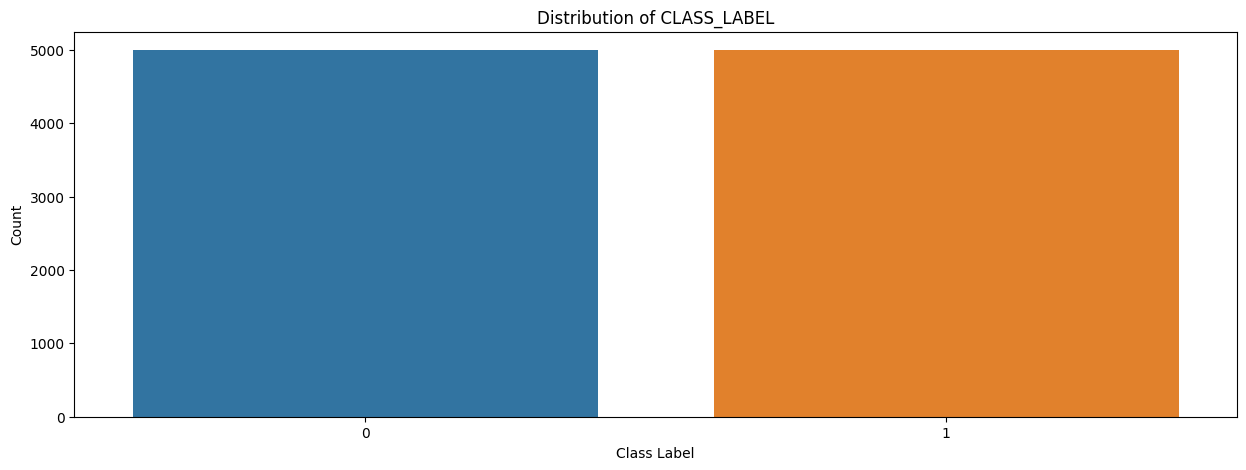

In [427]:
plt.figure(figsize=(15,5))
sns.countplot(x='CLASS_LABEL', data=df)
plt.title('Distribution of CLASS_LABEL')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

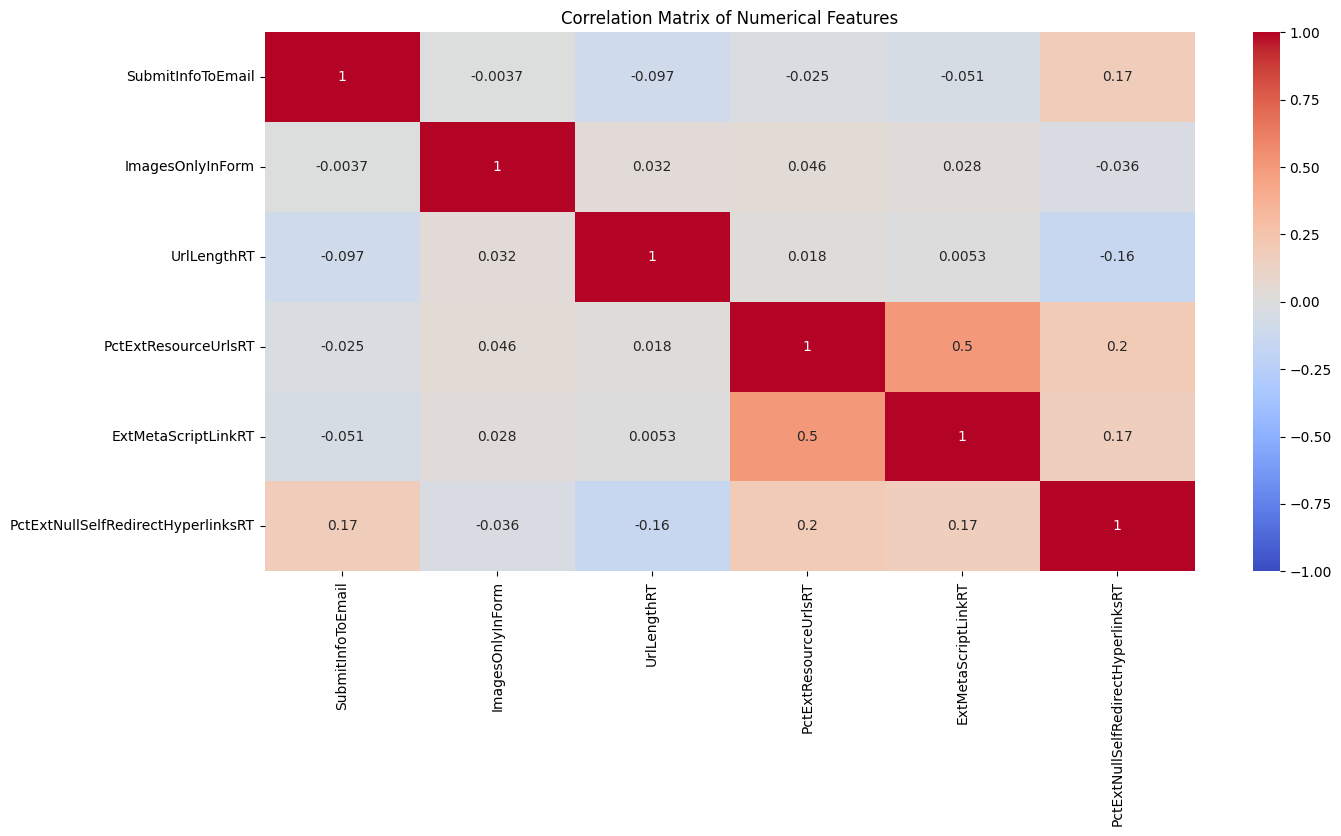

In [428]:
numerical_cols = ['SubmitInfoToEmail', 'ImagesOnlyInForm', 'UrlLengthRT', 
                  'PctExtResourceUrlsRT', 'ExtMetaScriptLinkRT', 
                  'PctExtNullSelfRedirectHyperlinksRT']
plt.figure(figsize=(15,7))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

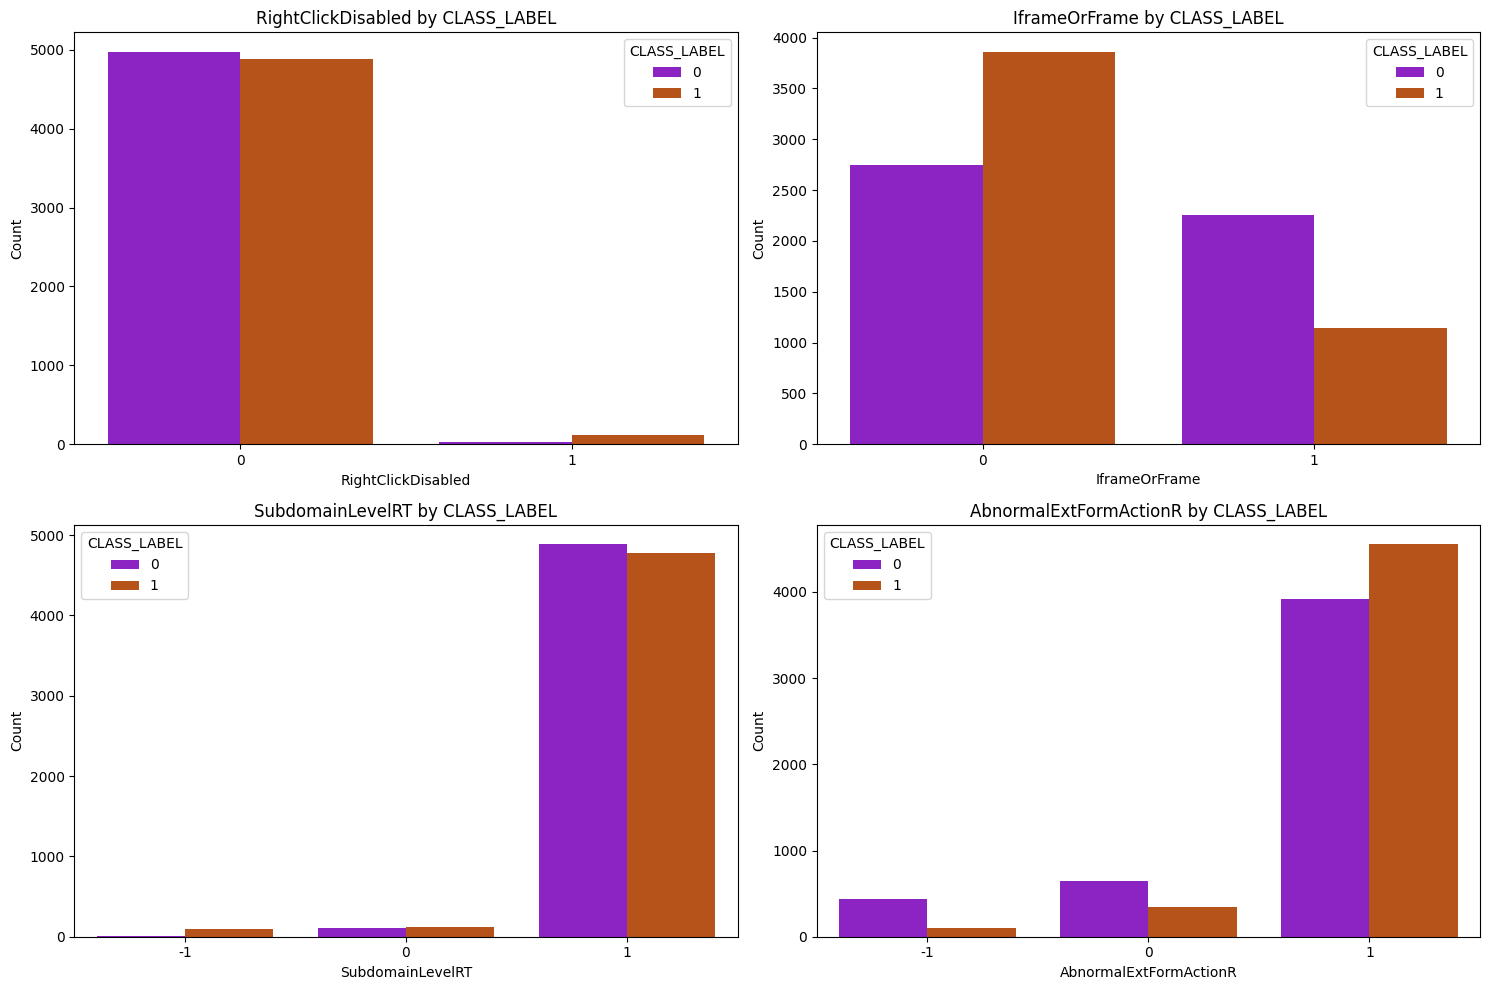

In [429]:
binary_cols = ['RightClickDisabled', 'IframeOrFrame', 'SubdomainLevelRT', 'AbnormalExtFormActionR']
n_cols = 2  # number of columns in the subplot grid
n_rows = (len(binary_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='CLASS_LABEL', data=df, ax=axes[i],palette="gnuplot")
    axes[i].set_title(f'{col} by CLASS_LABEL')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='CLASS_LABEL')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

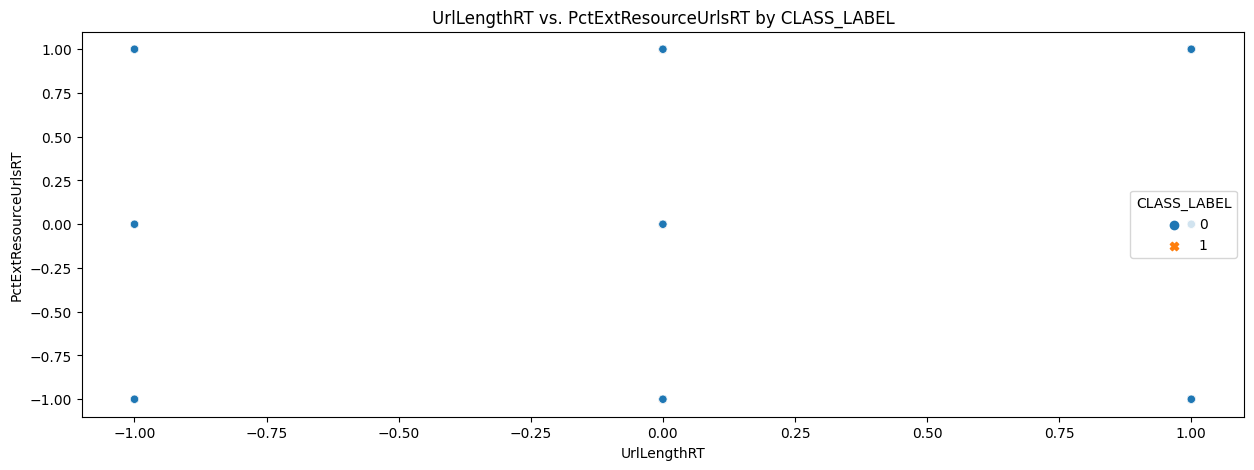

In [430]:
plt.figure(figsize=(15,5))
sns.scatterplot(x='UrlLengthRT', y='PctExtResourceUrlsRT', hue='CLASS_LABEL', style='CLASS_LABEL', data=df)
plt.title('UrlLengthRT vs. PctExtResourceUrlsRT by CLASS_LABEL')
plt.xlabel('UrlLengthRT')
plt.ylabel('PctExtResourceUrlsRT')
plt.show()

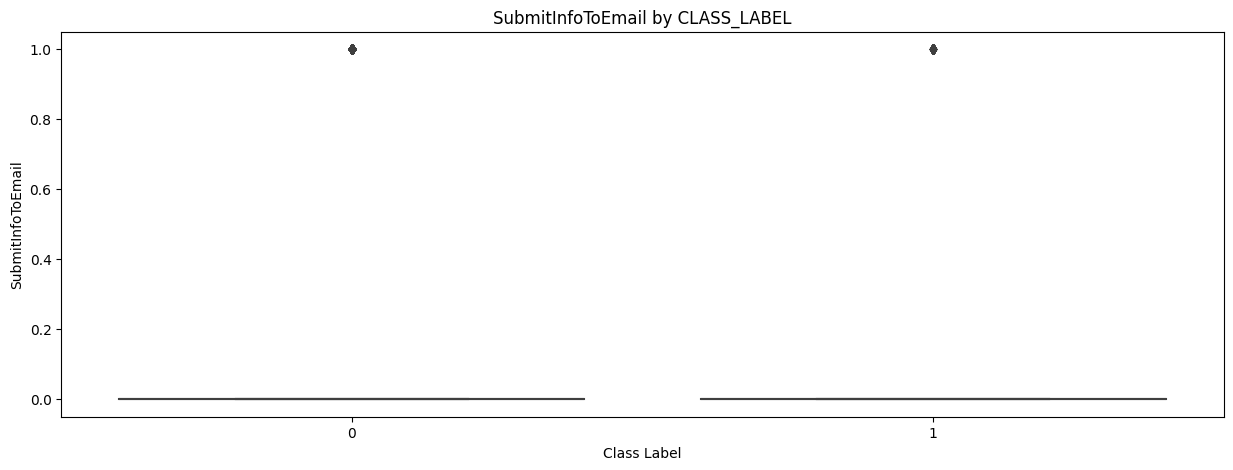

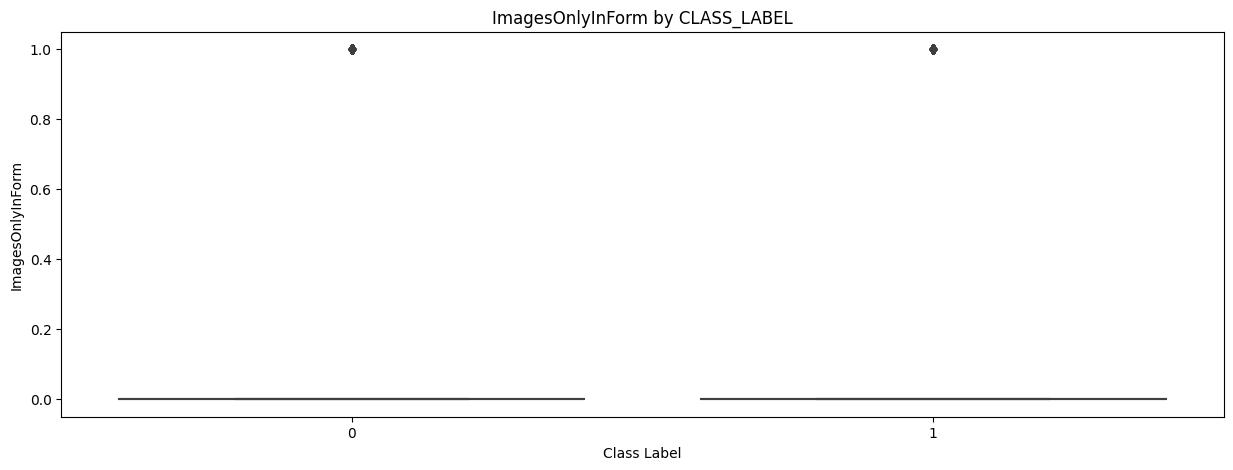

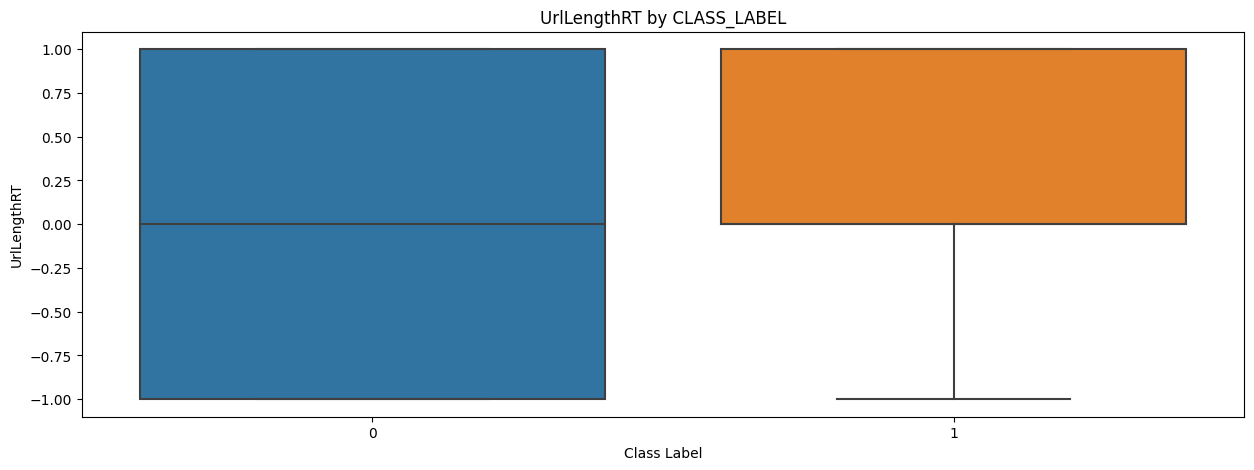

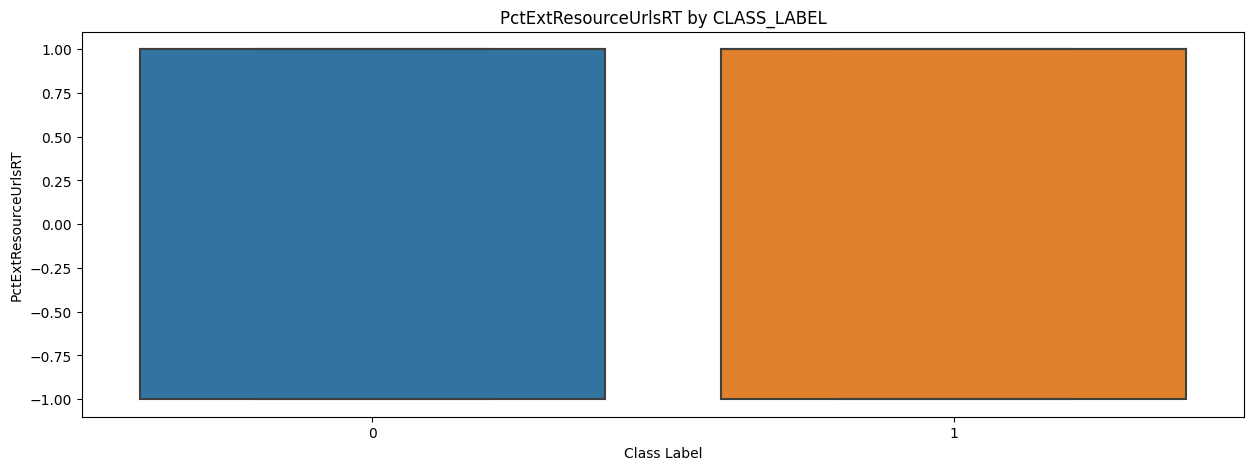

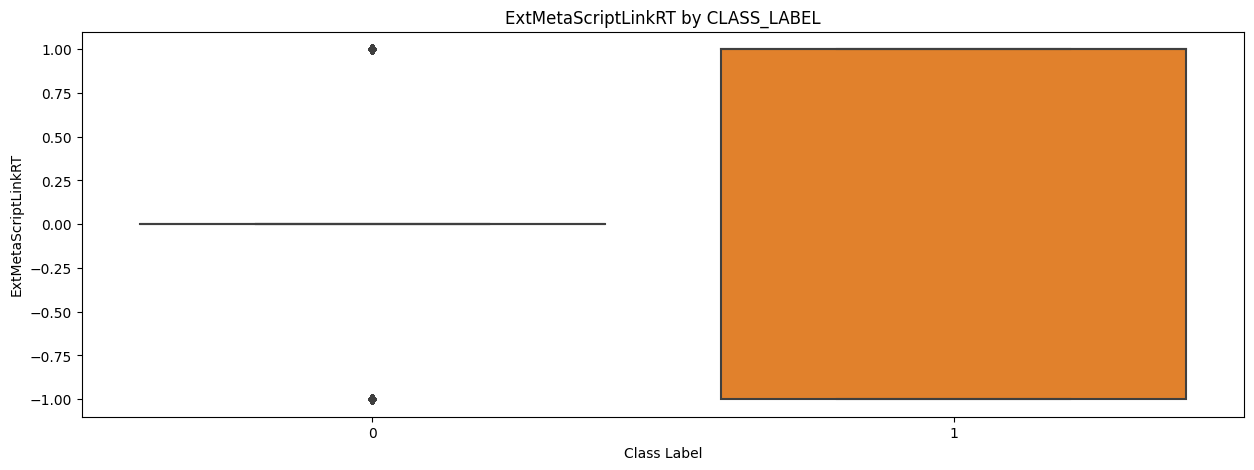

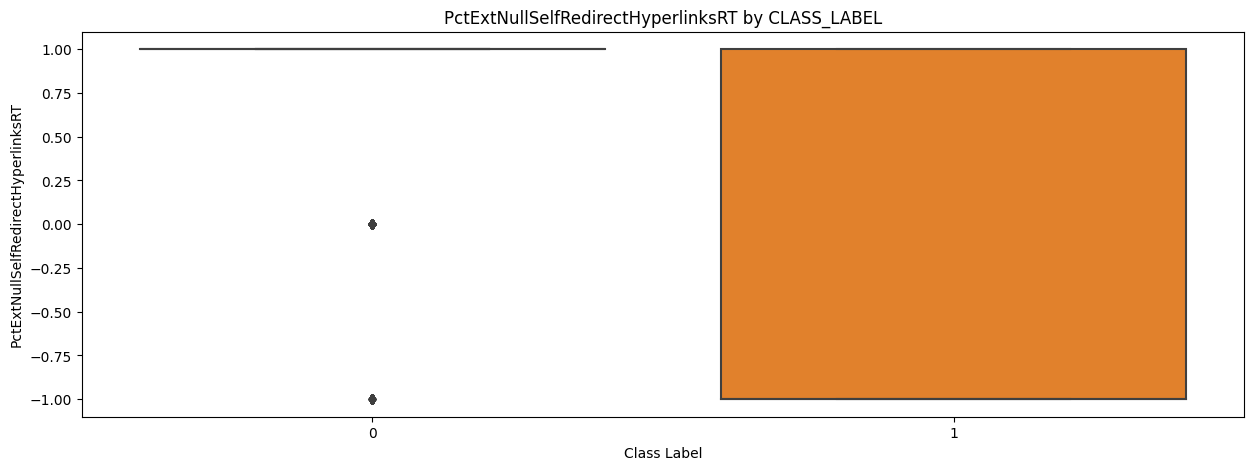

In [431]:
for col in numerical_cols:
    plt.figure(figsize=(15,5))
    sns.boxplot(x='CLASS_LABEL', y=col, data=df)
    plt.title(f'{col} by CLASS_LABEL')
    plt.xlabel('Class Label')
    plt.ylabel(col)
    plt.show()

In [432]:
df.head()

,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,NumHash,NumNumericChars,NoHttps,RandomString,IpAddress,DomainInSubdomains,DomainInPaths,HttpsInHostname,HostnameLength,PathLength,QueryLength,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,PctExtHyperlinks,PctExtResourceUrls,ExtFavicon,InsecureForms,RelativeFormAction,ExtFormAction,AbnormalFormAction,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,FakeLinkInStatusBar,RightClickDisabled,PopUpWindow,SubmitInfoToEmail,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,3,1,5,72,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,21,44,0,0,0,0,0.000,0.250000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,1,1,0,1,1,-1,1,1
1,3,1,3,144,0,0,0,0,2,0,2,1,0,41,1,0,0,0,0,0,17,16,103,0,1,0,0.000,0.000000,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,-1,1,1,1,1,1
2,3,1,2,58,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,27,24,0,0,0,0,0.375,1.000000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,0,-1,1,-1,0,1
3,3,1,6,79,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,22,50,0,0,0,1,1.000,0.095238,1,1,0,0,0,0.0,1,0,0,0,1,0,0,0,1,-1,1,1,1,-1,1
4,3,0,4,46,0,0,0,0,0,0,0,0,0,2,1,1,0,0,1,0,10,29,0,0,0,0,1.000,1.000000,0,0,0,1,0,0.0,1,0,0,0,0,1,0,0,1,1,-1,0,-1,-1,1


In [433]:
X=df.drop(columns=["CLASS_LABEL"],axis=1)
y=df["CLASS_LABEL"]

In [434]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    balanced_accuracy_score,
    cohen_kappa_score
)

model = RandomForestClassifier(random_state=42)
model.fit(X, y)
importances = model.feature_importances_
feature_names = X.columns

# Create DataFrame of feature importances
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select top 5 features
top_5_features = importance_df['Feature'].head(5).tolist()
print("Top 5 Features:", top_5_features)

# Create new_df with top 5 features and CLASS_LABEL
new_df = df[top_5_features + ['CLASS_LABEL']].copy()

Top 5 Features: ['PctExtHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'PctExtResourceUrls', 'FrequentDomainNameMismatch', 'PctNullSelfRedirectHyperlinks']


In [435]:
new_df = new_df.rename(columns={
    'PctExtHyperlinks': 'ExtLinks',
    'PctExtNullSelfRedirectHyperlinksRT': 'NullRedirectRisk',
    'PctExtResourceUrls': 'ExtResURLs',
    'FrequentDomainNameMismatch': 'DomainMismatch',
    'PctNullSelfRedirectHyperlinks': 'NullRedirects',
    'CLASS_LABEL': 'Label'
})


In [436]:
new_df['NullRedirectRisk'] = new_df['NullRedirectRisk'].replace(-1, 0)
new_df['ExtResURLs'] = pd.to_numeric(new_df['ExtResURLs'], errors='coerce')


In [437]:
new_df.head()

,ExtLinks,NullRedirectRisk,ExtResURLs,DomainMismatch,NullRedirects,Label
0,0.000,1,0.250000,0,0.0,1
1,0.000,1,0.000000,0,0.0,1
2,0.375,0,1.000000,0,0.0,1
3,1.000,0,0.095238,1,0.0,1
4,1.000,0,1.000000,1,0.0,1


In [438]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ExtLinks          10000 non-null  float64
 1   NullRedirectRisk  10000 non-null  int64  
 2   ExtResURLs        10000 non-null  float64
 3   DomainMismatch    10000 non-null  int64  
 4   NullRedirects     10000 non-null  float64
 5   Label             10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [439]:
min_val = new_df['ExtLinks'].min()
max_val = new_df['ExtLinks'].max()

bins = np.linspace(min_val - 0.01, max_val + 0.01, 6)

labels = ["Very Low", "Low", "Medium", "High", "Very High"]

new_df['ExtLinks'] = pd.cut(new_df['ExtLinks'], bins=bins, labels=labels)

In [440]:
min_val = new_df['ExtResURLs'].min()
max_val = new_df['ExtResURLs'].max()
bins = np.linspace(min_val - 0.01, max_val + 0.01, 6)  # 6 edges = 5 bins

labels = ["Very Low", "Low", "Medium", "High", "Very High"]

new_df['ExtResURLs'] = pd.cut(new_df['ExtResURLs'], bins=bins, labels=labels)

In [441]:
min_val = new_df['NullRedirects'].min()
max_val = new_df['NullRedirects'].max()


bins = np.linspace(min_val - 0.001, max_val + 0.001, 6)

labels = ["Very Low", "Low", "Medium", "High", "Very High"]

new_df['NullRedirects'] = pd.cut(new_df['NullRedirects'], bins=bins, labels=labels)


In [442]:
mapping = {
    "Very Low": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Very High": 4
}

new_df['ExtLinks'] = new_df['ExtLinks'].map(mapping)
new_df['ExtResURLs'] = new_df['ExtResURLs'].map(mapping)
new_df['NullRedirects'] = new_df['NullRedirects'].map(mapping)

# For the feature NullRedirectRisk with values 0 and 1, typically:

- 0 means No Risk — the website does not have null or self-redirect hyperlinks (safe behavior).

- 1 means Risk Present — the website has null or self-redirect hyperlinks, which is suspicious and could be a phishing indicator.

# 0==Legit
# 1==Phishing

In [443]:
new_df.head()


,ExtLinks,NullRedirectRisk,ExtResURLs,DomainMismatch,NullRedirects,Label
0,0,1,1,0,0,1
1,0,1,0,0,0,1
2,1,0,4,0,0,1
3,4,0,0,1,0,1
4,4,0,4,1,0,1


In [444]:
cat_cols = ['ExtLinks', 'ExtResURLs', 'NullRedirects']

for col in cat_cols:
    new_df[col] = new_df[col].cat.codes


In [445]:

from sklearn.model_selection import train_test_split
X=new_df.drop(columns=["Label"],axis=1)
y=new_df["Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [452]:
from catboost import CatBoostClassifier
model = CatBoostClassifier(verbose=100, random_seed=42,learning_rate=0.1,iterations=2000,max_depth=6)
model.fit(X_train, y_train)

0:	learn: 0.6056766	total: 2.82ms	remaining: 5.63s
100:	learn: 0.3426458	total: 279ms	remaining: 5.24s
200:	learn: 0.3408464	total: 556ms	remaining: 4.97s
300:	learn: 0.3406384	total: 816ms	remaining: 4.61s
400:	learn: 0.3405934	total: 1.06s	remaining: 4.25s
500:	learn: 0.3405502	total: 1.31s	remaining: 3.92s
600:	learn: 0.3405498	total: 1.55s	remaining: 3.6s
700:	learn: 0.3405466	total: 1.79s	remaining: 3.31s
800:	learn: 0.3405350	total: 2.03s	remaining: 3.03s
900:	learn: 0.3405287	total: 2.27s	remaining: 2.77s
1000:	learn: 0.3405218	total: 2.51s	remaining: 2.51s
1100:	learn: 0.3405125	total: 2.75s	remaining: 2.24s
1200:	learn: 0.3404883	total: 2.99s	remaining: 1.99s
1300:	learn: 0.3404736	total: 3.23s	remaining: 1.73s
1400:	learn: 0.3404685	total: 3.46s	remaining: 1.48s
1500:	learn: 0.3404613	total: 3.7s	remaining: 1.23s
1600:	learn: 0.3404548	total: 3.93s	remaining: 979ms
1700:	learn: 0.3404492	total: 4.16s	remaining: 732ms
1800:	learn: 0.3404466	total: 4.4s	remaining: 486ms
1900:	l

In [453]:
y_pred=model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Cohen Kappa Score:", cohen_kappa_score(y_test, y_pred))
print("Matthews Correlation Coefficient:", matthews_corrcoef(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8025
Precision: 0.9639097744360903
Recall: 0.633399209486166
F1 Score: 0.7644603458556948
Cohen Kappa Score: 0.6065815422003545
Matthews Correlation Coefficient: 0.6464149185074312

Confusion Matrix:
 [[964  24]
 [371 641]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.98      0.83       988
           1       0.96      0.63      0.76      1012

    accuracy                           0.80      2000
   macro avg       0.84      0.80      0.80      2000
weighted avg       0.84      0.80      0.80      2000



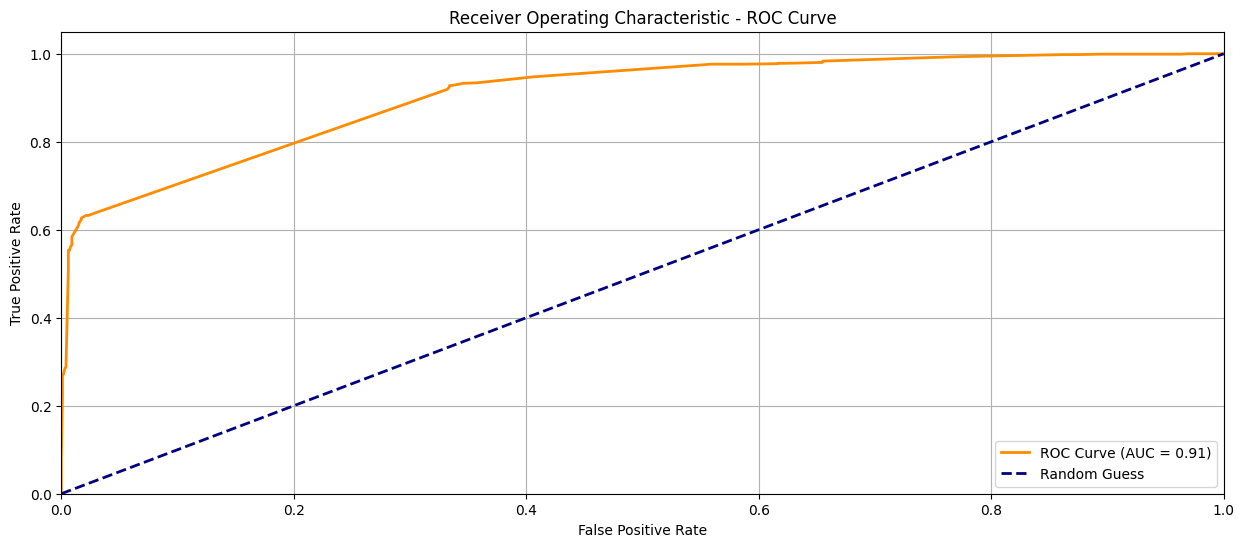

In [454]:
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities for the positive class (phishing == 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(15, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


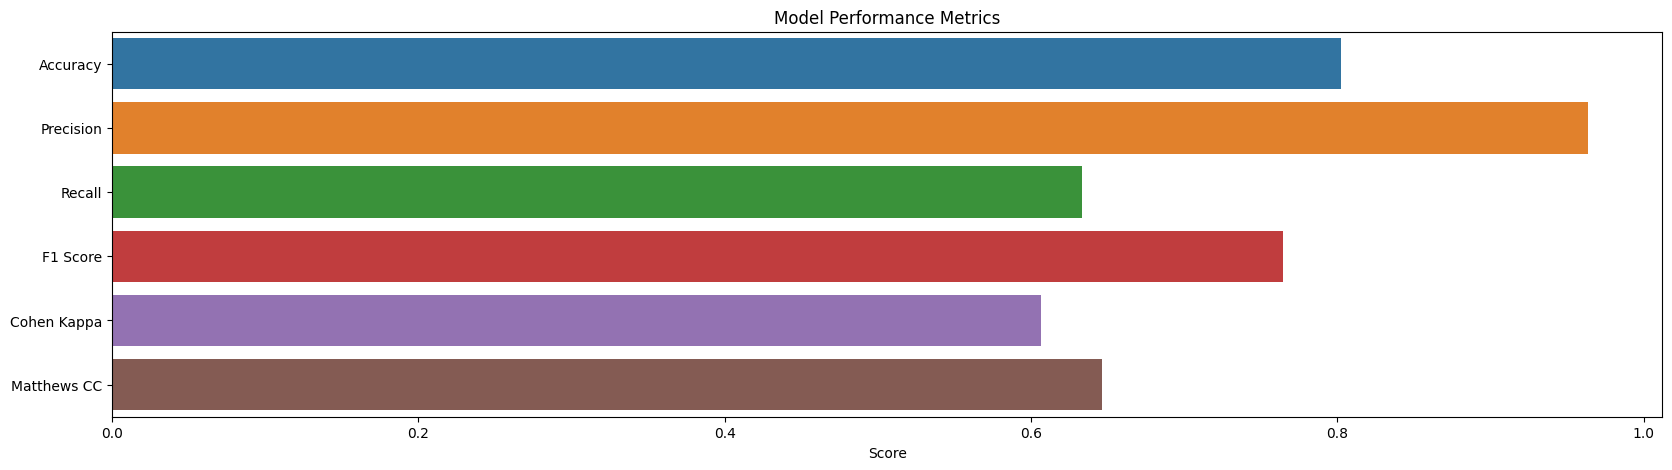

In [455]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label=1),
    'Recall': recall_score(y_test, y_pred, pos_label=1),
    'F1 Score': f1_score(y_test, y_pred, pos_label=1),
    'Cohen Kappa': cohen_kappa_score(y_test, y_pred),
    'Matthews CC': matthews_corrcoef(y_test, y_pred)
}
plt.figure(figsize=(20,5))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()))
plt.title('Model Performance Metrics')
plt.xlabel('Score')
plt.show()

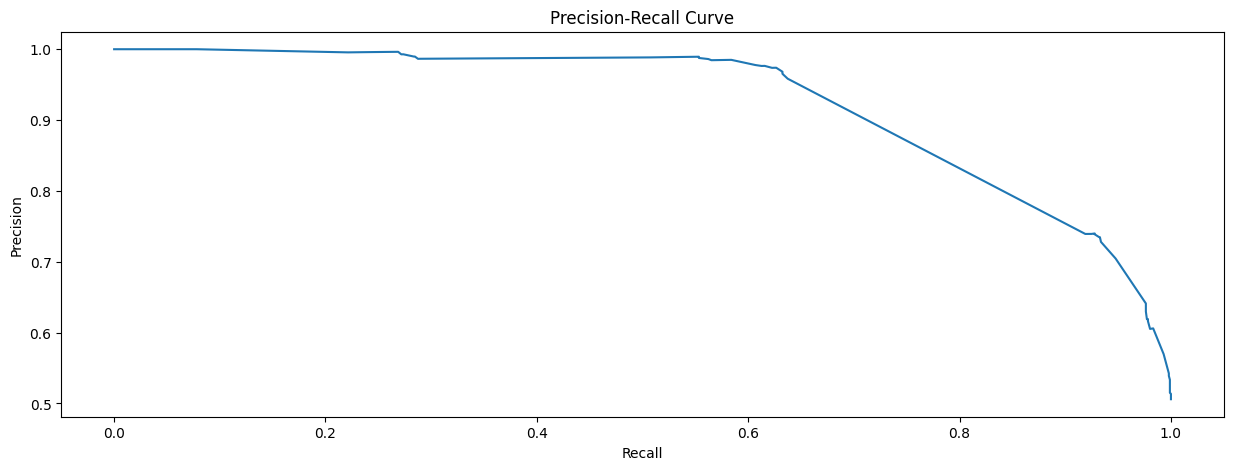

In [458]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba, pos_label=1)
plt.figure(figsize=(15,5))
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


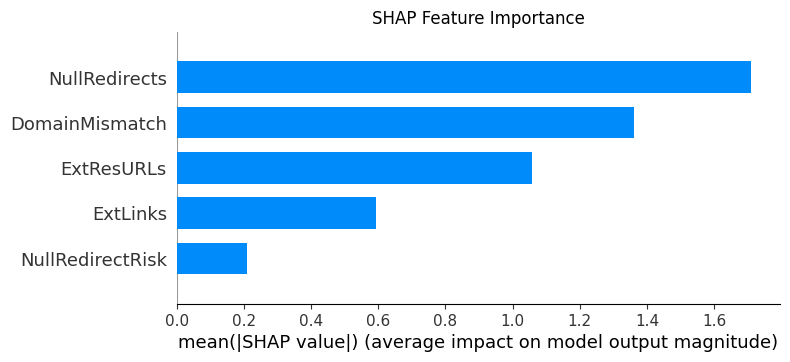

In [462]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


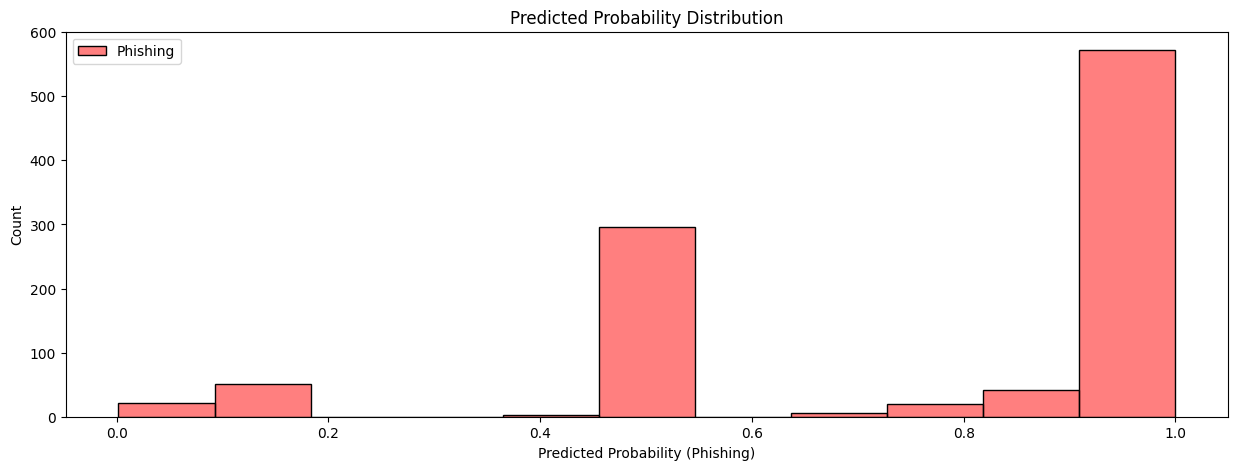

In [463]:
plt.figure(figsize=(15,5))
sns.histplot(y_pred_proba[y_test == 1], color='red', label='Phishing', alpha=0.5)
sns.histplot(y_pred_proba[y_test == -1], color='blue', label='Legitimate', alpha=0.5)
plt.title('Predicted Probability Distribution')
plt.xlabel('Predicted Probability (Phishing)')
plt.legend()
plt.show()

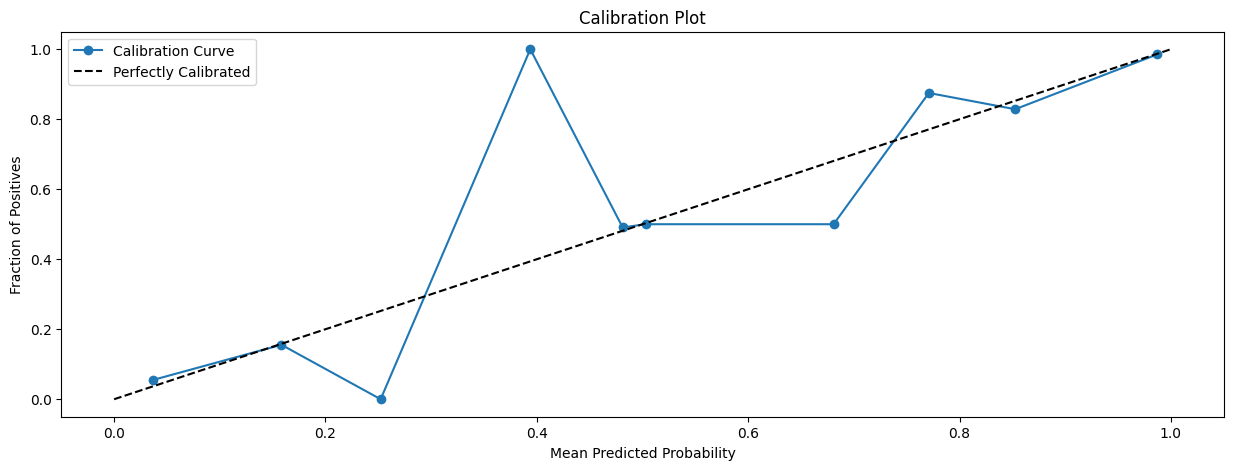

In [465]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, pos_label=1, n_bins=10)
plt.figure(figsize=(15,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.title('Calibration Plot')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

In [466]:
import pickle
f=open("catboost_classifier.pkl","wb")
pickle.dump(model,f)
f.close()